In [2]:
from datasets import load_dataset
import pandas as pd

# Load dataset
dataset = load_dataset("Tobi-Bueck/customer-support-tickets")

# Convert to pandas DataFrame
df = dataset["train"].to_pandas()

print(df.head())

/Users/harshalbhujade/MegaProject/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


                                             subject  \
0                    Wesentlicher Sicherheitsvorfall   
1                                 Account Disruption   
2  Query About Smart Home System Integration Feat...   
3                  Inquiry Regarding Invoice Details   
4  Question About Marketing Agency Software Compa...   

                                                body  \
0  Sehr geehrtes Support-Team,\n\nich möchte eine...   
1  Dear Customer Support Team,\n\nI am writing to...   
2  Dear Customer Support Team,\n\nI hope this mes...   
3  Dear Customer Support Team,\n\nI hope this mes...   
4  Dear Support Team,\n\nI hope this message reac...   

                                              answer      type  \
0  Vielen Dank für die Meldung des kritischen Sic...  Incident   
1  Thank you for reaching out, <name>. We are awa...  Incident   
2  Thank you for your inquiry. Our products suppo...   Request   
3  We appreciate you reaching out with your billi...   Request

In [3]:
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [4]:
df.tail()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
61760,Assistance Needed for IFTTT Docker Integration,I am facing integration problems with IFTTT Do...,I would be happy to assist with the IFTTT Dock...,Problem,Technical Support,low,en,NaN,Integration,Disruption,Performance,IT,Tech Support,NaN,NaN,NaN
61761,Bitten um Unterstützung bei der Integration,"Sehr geehrte Kundenservice, ich möchte die Int...","Sehr geehrte [Name], vielen Dank für Ihren Kon...",Change,Technical Support,medium,de,NaN,Integration,Feature,Documentation,Tech Support,NaN,NaN,NaN,NaN
61762,NaN,"Hello Customer Support, I am inquiring about t...",We will send you detailed information on plans...,Request,Billing and Payments,low,en,NaN,Billing,Payment,Feature,Feedback,Sales,Lead,NaN,NaN
61763,Hilfe bei digitalen Strategie-Problemen,Die Qualität unserer digitalen Strategie-Bearb...,Um den digitalen Strategie-Impuls zu überprüfe...,Incident,Product Support,high,de,NaN,Feedback,Performance,IT,Tech Support,NaN,NaN,NaN,NaN
61764,Optimierung Ihrer Datenanalyse-Plattform erlei...,"Sehr geehrte Customer Support-Team, ich schrei...","Sehr geehrter <name>, wir antworten Ihnen auf ...",Change,Sales and Pre-Sales,medium,de,NaN,Product,Feature,Performance,Guidance,Documentation,NaN,NaN,NaN


In [5]:
print(df.shape)

(61765, 16)


In [6]:
print(df.columns)

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='str')


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  str    
 1   body      61763 non-null  str    
 2   answer    48576 non-null  str    
 3   type      48587 non-null  str    
 4   queue     61765 non-null  str    
 5   priority  61765 non-null  str    
 6   language  61765 non-null  str    
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  str    
 9   tag_2     48528 non-null  str    
 10  tag_3     48356 non-null  str    
 11  tag_4     43990 non-null  str    
 12  tag_5     27636 non-null  str    
 13  tag_6     13225 non-null  str    
 14  tag_7     5968 non-null   str    
 15  tag_8     2472 non-null   str    
dtypes: float64(1), str(15)
memory usage: 57.2 MB


In [8]:
missing = df.isnull().sum()

missing_df = missing.to_frame(name="Missing Values")
missing_df["Percentage"] = (missing_df["Missing Values"] / len(df)) * 100
missing_df.sort_values(by="Missing Values", ascending=False)

,Missing Values,Percentage
tag_8,59293,95.997733
tag_7,55797,90.337570
tag_6,48540,78.588197
tag_5,34129,55.256213
version,33178,53.716506
tag_4,17775,28.778434
tag_3,13409,21.709706
tag_2,13237,21.431231
answer,13189,21.353517
type,13178,21.335708


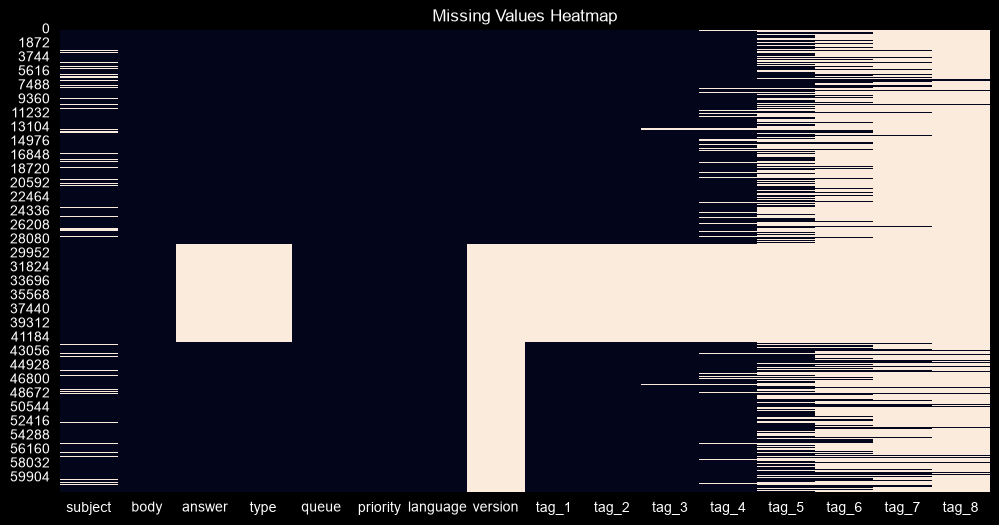

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [10]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


Observation: The dataset contains 0 duplicate rows, indicating that each support ticket is unique. Therefore, no duplicate records need to be removed during the data preprocessing stage.

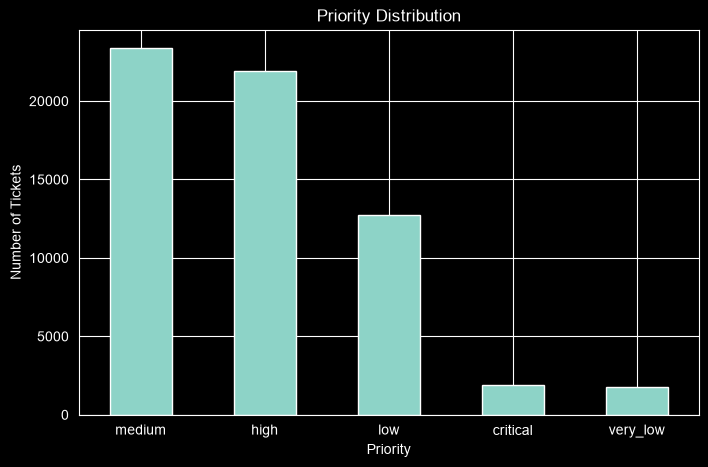

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["priority"].value_counts().plot(kind="bar")

plt.title("Priority Distribution")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)

plt.show()

In [12]:
df["priority"].value_counts()

priority
medium      23378
high        21925
low         12765
critical     1914
very_low     1783
Name: count, dtype: int64

The majority of support tickets are marked as Medium (23,378) and High (21,925) priority. Low priority tickets account for 12,765 cases, while Critical (1,914) and Very Low (1,783) tickets are relatively rare. This indicates that most support requests require moderate to high attention.

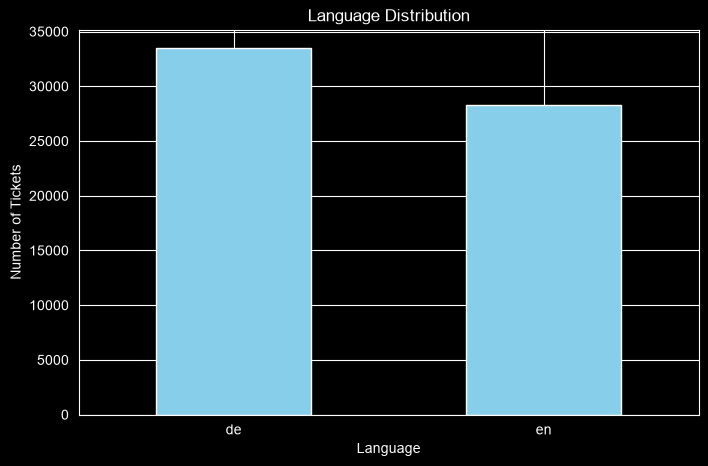

language
de    33504
en    28261
Name: count, dtype: int64


In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df["language"].value_counts().plot(kind="bar", color="skyblue")

plt.title("Language Distribution")
plt.xlabel("Language")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=0)

plt.show()

print(df["language"].value_counts())

language
de    33504
en    28261
Name: count, dtype: int64


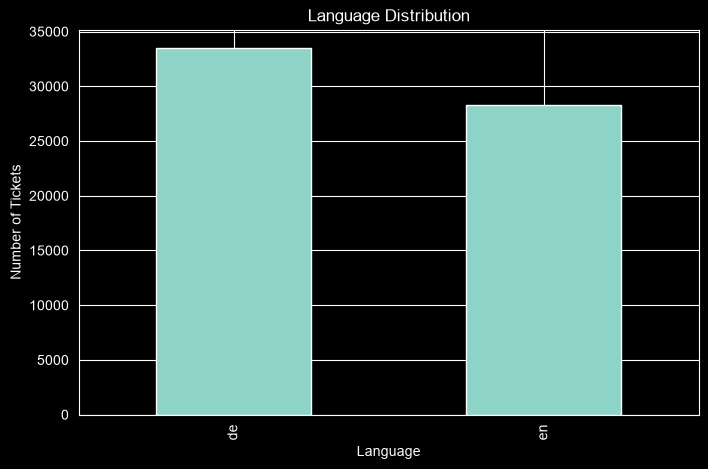

In [14]:
import matplotlib.pyplot as plt

language_counts = df["language"].value_counts()

print(language_counts)

plt.figure(figsize=(8,5))
language_counts.plot(kind="bar")

plt.title("Language Distribution")
plt.xlabel("Language")
plt.ylabel("Number of Tickets")

plt.show()

queue
Technical Support                         14186
Product Support                            8960
Customer Service                           7420
IT Support                                 5725
Billing and Payments                       4874
Returns and Exchanges                      2438
Service Outages and Maintenance            1912
Sales and Pre-Sales                        1490
Human Resources                             914
General Inquiry                             668
Pets & Animals/Pet Services                 386
News                                        383
IT & Technology/Security Operations         365
Autos & Vehicles/Sales                      364
Health/Medical Services                     362
Home & Garden/Home Improvement              361
Pets & Animals/Veterinary Care              356
Health/Mental Health                        347
Business & Industrial/Manufacturing         346
Online Communities/Forums                   343
Shopping/E-commerce               

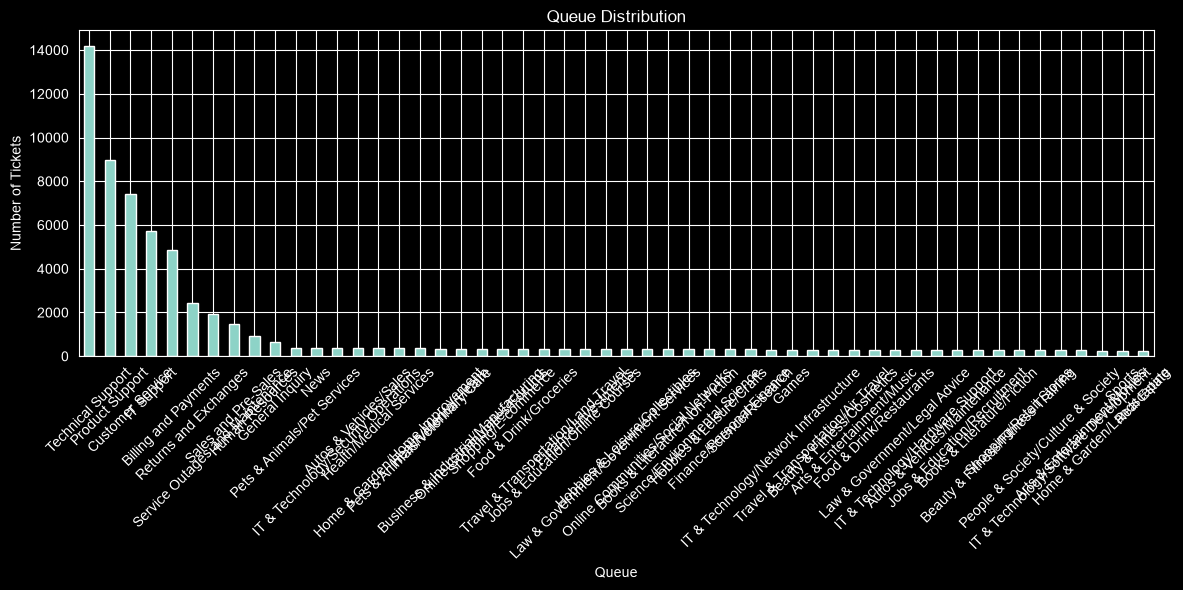

In [15]:
queue_counts = df["queue"].value_counts()

print(queue_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
queue_counts.plot(kind="bar")

plt.title("Queue Distribution")
plt.xlabel("Queue")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

count    61765.000000
mean       419.179422
std        223.859775
min          0.000000
25%        234.000000
50%        415.000000
75%        587.000000
max       2259.000000
Name: body_length, dtype: float64


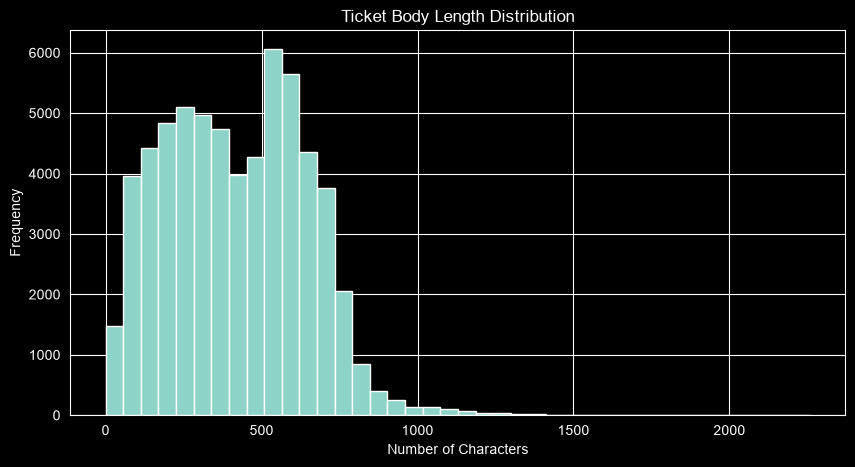

In [16]:
# Ticket body length
df["body_length"] = df["body"].fillna("").str.len()

print(df["body_length"].describe())

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(df["body_length"], bins=40)

plt.title("Ticket Body Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")

plt.show()

type
Incident    19444
Request     13950
Problem     10196
Change       4997
Name: count, dtype: int64


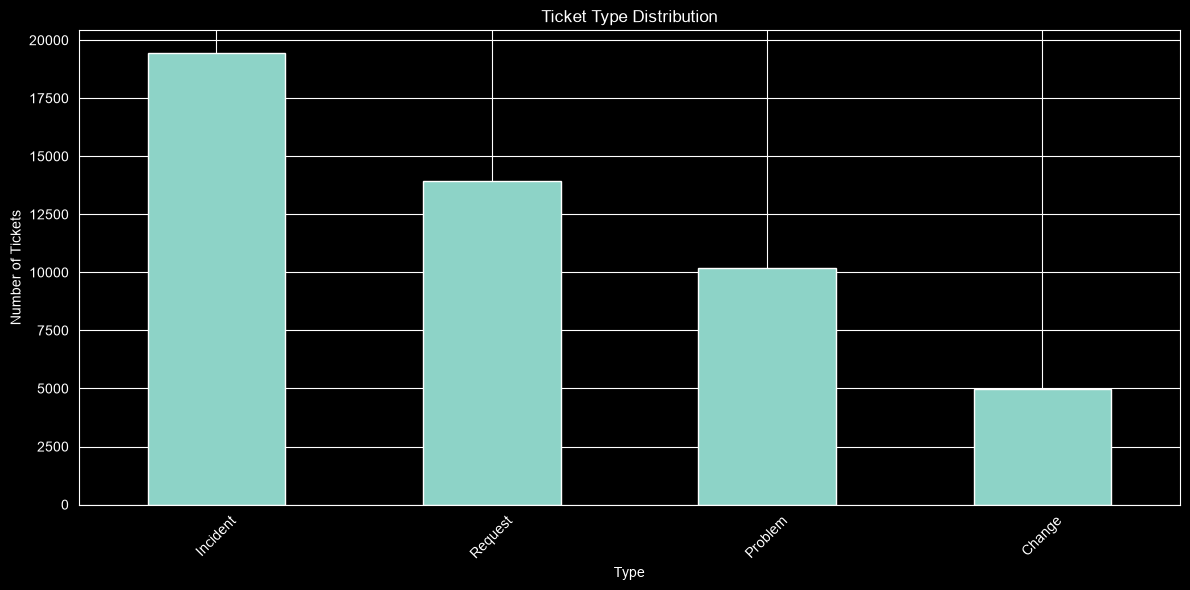

In [17]:
type_counts = df["type"].value_counts()

print(type_counts)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
type_counts.plot(kind="bar")

plt.title("Ticket Type Distribution")
plt.xlabel("Type")
plt.ylabel("Number of Tickets")
1
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

The dataset contains four ticket types. Incident is the most frequent ticket type, followed by Request and Problem, while Change requests are the least common. The classes are moderately imbalanced and this should be considered during model training.

DATA CLEANING

In [18]:
# Essential columns
essential_cols = [
    "subject",
    "body",
    "type",
    "priority",
    "queue",
    "language",
    "answer"
]

df[essential_cols].isnull().sum()

subject      5299
body            2
type        13178
priority        0
queue           0
language        0
answer      13189
dtype: int64

from this if i remove each row with missing value then, we'll lose more than 13,000 tickets
so we let each model use the columns it needs

In [19]:
# Remove rows where body is missing
df = df.dropna(subset=["body"])

print(df.shape)

(61763, 17)


In [26]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='str')

In [27]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6',
       'tag_7', 'tag_8'],
      dtype='str')

In [28]:
for col in ["version", "tag_1", "tag_2", "tag_3", "tag_4", "tag_5", "tag_6", "tag_7", "tag_8"]:
    print(f"\n{'='*20} {col} {'='*20}")
    print(df[col].value_counts().head(10))


==================== version ====================
version
400.0    18599
52.0      9119
51.0       869
Name: count, dtype: int64

==================== tag_1 ====================
tag_1
Security       9156
Bug            7665
Feedback       5409
Technical      5032
Feature        4424
Performance    3865
Billing        2485
Outage         1755
Network        1482
Customer       1049
Name: count, dtype: int64

==================== tag_2 ====================
tag_2
Performance      8698
IT               3900
Bug              3133
Documentation    2949
Sales            2407
Disruption       2398
Feedback         2240
Product          2128
Network          2088
Outage           1908
Name: count, dtype: int64

==================== tag_3 ====================
tag_3
IT               9430
Performance      4334
Tech Support     3931
Documentation    2900
Feedback         2733
Feature          2402
Disruption       2209
Bug              1842
Outage           1602
Product          1411
Name: count, 

MASTER DATASET

In [30]:
clean_df = df[
    [
        "subject",
        "body",
        "answer",
        "type",
        "priority",
        "queue",
        "language"
    ]
].copy()

In [31]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 61763 entries, 0 to 61764
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   56464 non-null  str  
 1   body      61763 non-null  str  
 2   answer    48574 non-null  str  
 3   type      48585 non-null  str  
 4   priority  61763 non-null  str  
 5   queue     61763 non-null  str  
 6   language  61763 non-null  str  
dtypes: str(7)
memory usage: 51.6 MB


In [32]:
for col in clean_df.columns:
    empty = (clean_df[col].astype(str).str.strip() == "").sum()
    print(f"{col}: {empty}")

subject: 0
body: 0
answer: 0
type: 0
priority: 0
queue: 0
language: 0


In [33]:
clean_df["subject"] = clean_df["subject"].fillna(
    clean_df["body"].str[:80]
)

In [34]:
clean_df["subject"].isnull().sum()

np.int64(0)

In [35]:
clean_df.to_csv("cleaned_itsm_master.csv", index=False)

In [36]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 61763 entries, 0 to 61764
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   subject   61763 non-null  str  
 1   body      61763 non-null  str  
 2   answer    48574 non-null  str  
 3   type      48585 non-null  str  
 4   priority  61763 non-null  str  
 5   queue     61763 non-null  str  
 6   language  61763 non-null  str  
dtypes: str(7)
memory usage: 52.0 MB
